# This Notebook Aims to Modify the Inputs

The updates will be performed initially on the 'clean_data.csv'

## Importing

In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))
from src.graph import univariate_plot
from src.clean import log_transform,  standard_scaling, classification_formulation, binary_classification_formulation

import pandas as pd

In [2]:
data = pd.read_csv('../data/processed/clean_data.csv')

## Adding New Inputs

Adding the input 'rooms_per_household'

In [3]:
data["rooms_per_household"] = data["total_rooms"] / data["households"]

Adding the input 'bedrooms_per_room', which is the proportion of bedrooms

In [4]:
data['bedrooms_per_room'] = data["total_bedrooms"] / data["total_rooms"]

Adding the input 'population_per_household', which is the proportion of bedrooms

In [5]:
data['population_per_household'] = data['population'] / data['households']

Reorder the columns to make the boolean columns last

In [6]:
data= data[
    list(data.columns[0:9]) +
    list(data.columns[14:]) +
    list(data.columns[9:14])
]

Check a sample

In [7]:
data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household
19973,-118.93,36.19,30.0,2685.0,546.0,951.0,523.0,2.6184,113900.0,0.203352,1.818356,0,1,0,0,5.133843
16361,-121.30,38.01,29.0,2289.0,449.0,1215.0,435.0,3.2788,100000.0,0.196156,2.793103,0,1,0,0,5.262069
16779,-122.48,37.68,31.0,3506.0,653.0,2296.0,645.0,5.5647,268700.0,0.186252,3.559690,0,0,1,0,5.435659
7168,-118.17,34.06,43.0,464.0,435.0,416.0,120.0,2.4750,142600.0,0.937500,3.466667,1,0,0,0,3.866667
16920,-122.33,37.57,43.0,2543.0,621.0,1301.0,606.0,3.1111,318400.0,0.244200,2.146865,0,0,1,0,4.196370


## Re-Visualize the Old Columns and Visualize Newer Ones as Histograms and BoxPlots

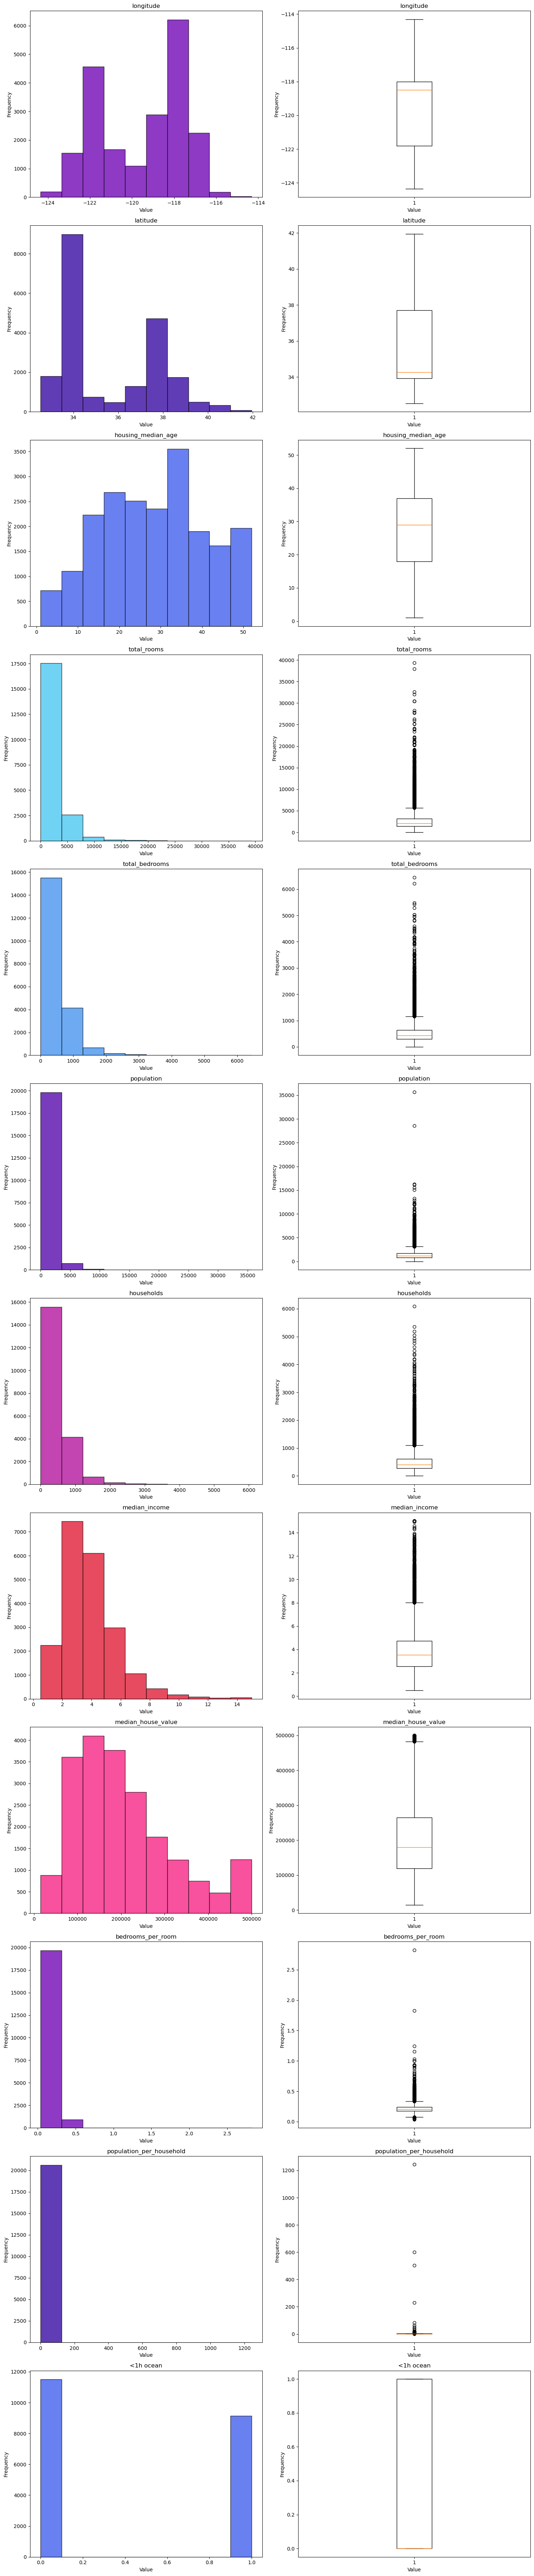

In [8]:
univariate_plot(data, 0, 12)

## Modifying the Skewed Columns using Log Transformation

In [9]:
data = log_transform(data, ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'])

In [10]:
data.sample(5)

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,<1h ocean,inland,near ocean,island,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income
19851,-119.21,36.39,31.0,53500.0,0.206826,3.410774,0,1,0,0,4.932660,7.290293,5.717028,6.921658,5.697093,1.110640
3355,-120.57,40.43,15.0,71500.0,0.225428,2.788557,0,1,0,0,5.087065,7.623642,6.135565,7.022868,5.998937,1.305681
14231,-117.04,32.68,9.0,125000.0,0.197279,2.751799,0,0,1,0,5.552158,8.035279,6.413459,7.333676,6.322565,1.563394
18836,-122.64,41.73,36.0,71200.0,0.200060,2.364501,0,1,0,0,5.259905,8.107720,6.499787,7.308543,6.448889,1.054103
5230,-118.24,33.93,37.0,86300.0,0.251217,3.322581,1,0,0,0,4.141129,6.935370,5.556828,6.715383,5.517453,0.921557


Reorder columns

In [11]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', '<1h ocean', 'inland',
       'near ocean', 'island', 'rooms_per_household', 'log_total_rooms',
       'log_total_bedrooms', 'log_population', 'log_households',
       'log_median_income'],
      dtype='object')

In [12]:
data = data[
    list(data.columns[0:6])+
    list(data.columns[10:])+
    list(data.columns[6:10])
]

In [13]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'bedrooms_per_room', 'population_per_household', 'rooms_per_household',
       'log_total_rooms', 'log_total_bedrooms', 'log_population',
       'log_households', 'log_median_income', '<1h ocean', 'inland',
       'near ocean', 'island'],
      dtype='object')

## Revisualize Transformed Columns

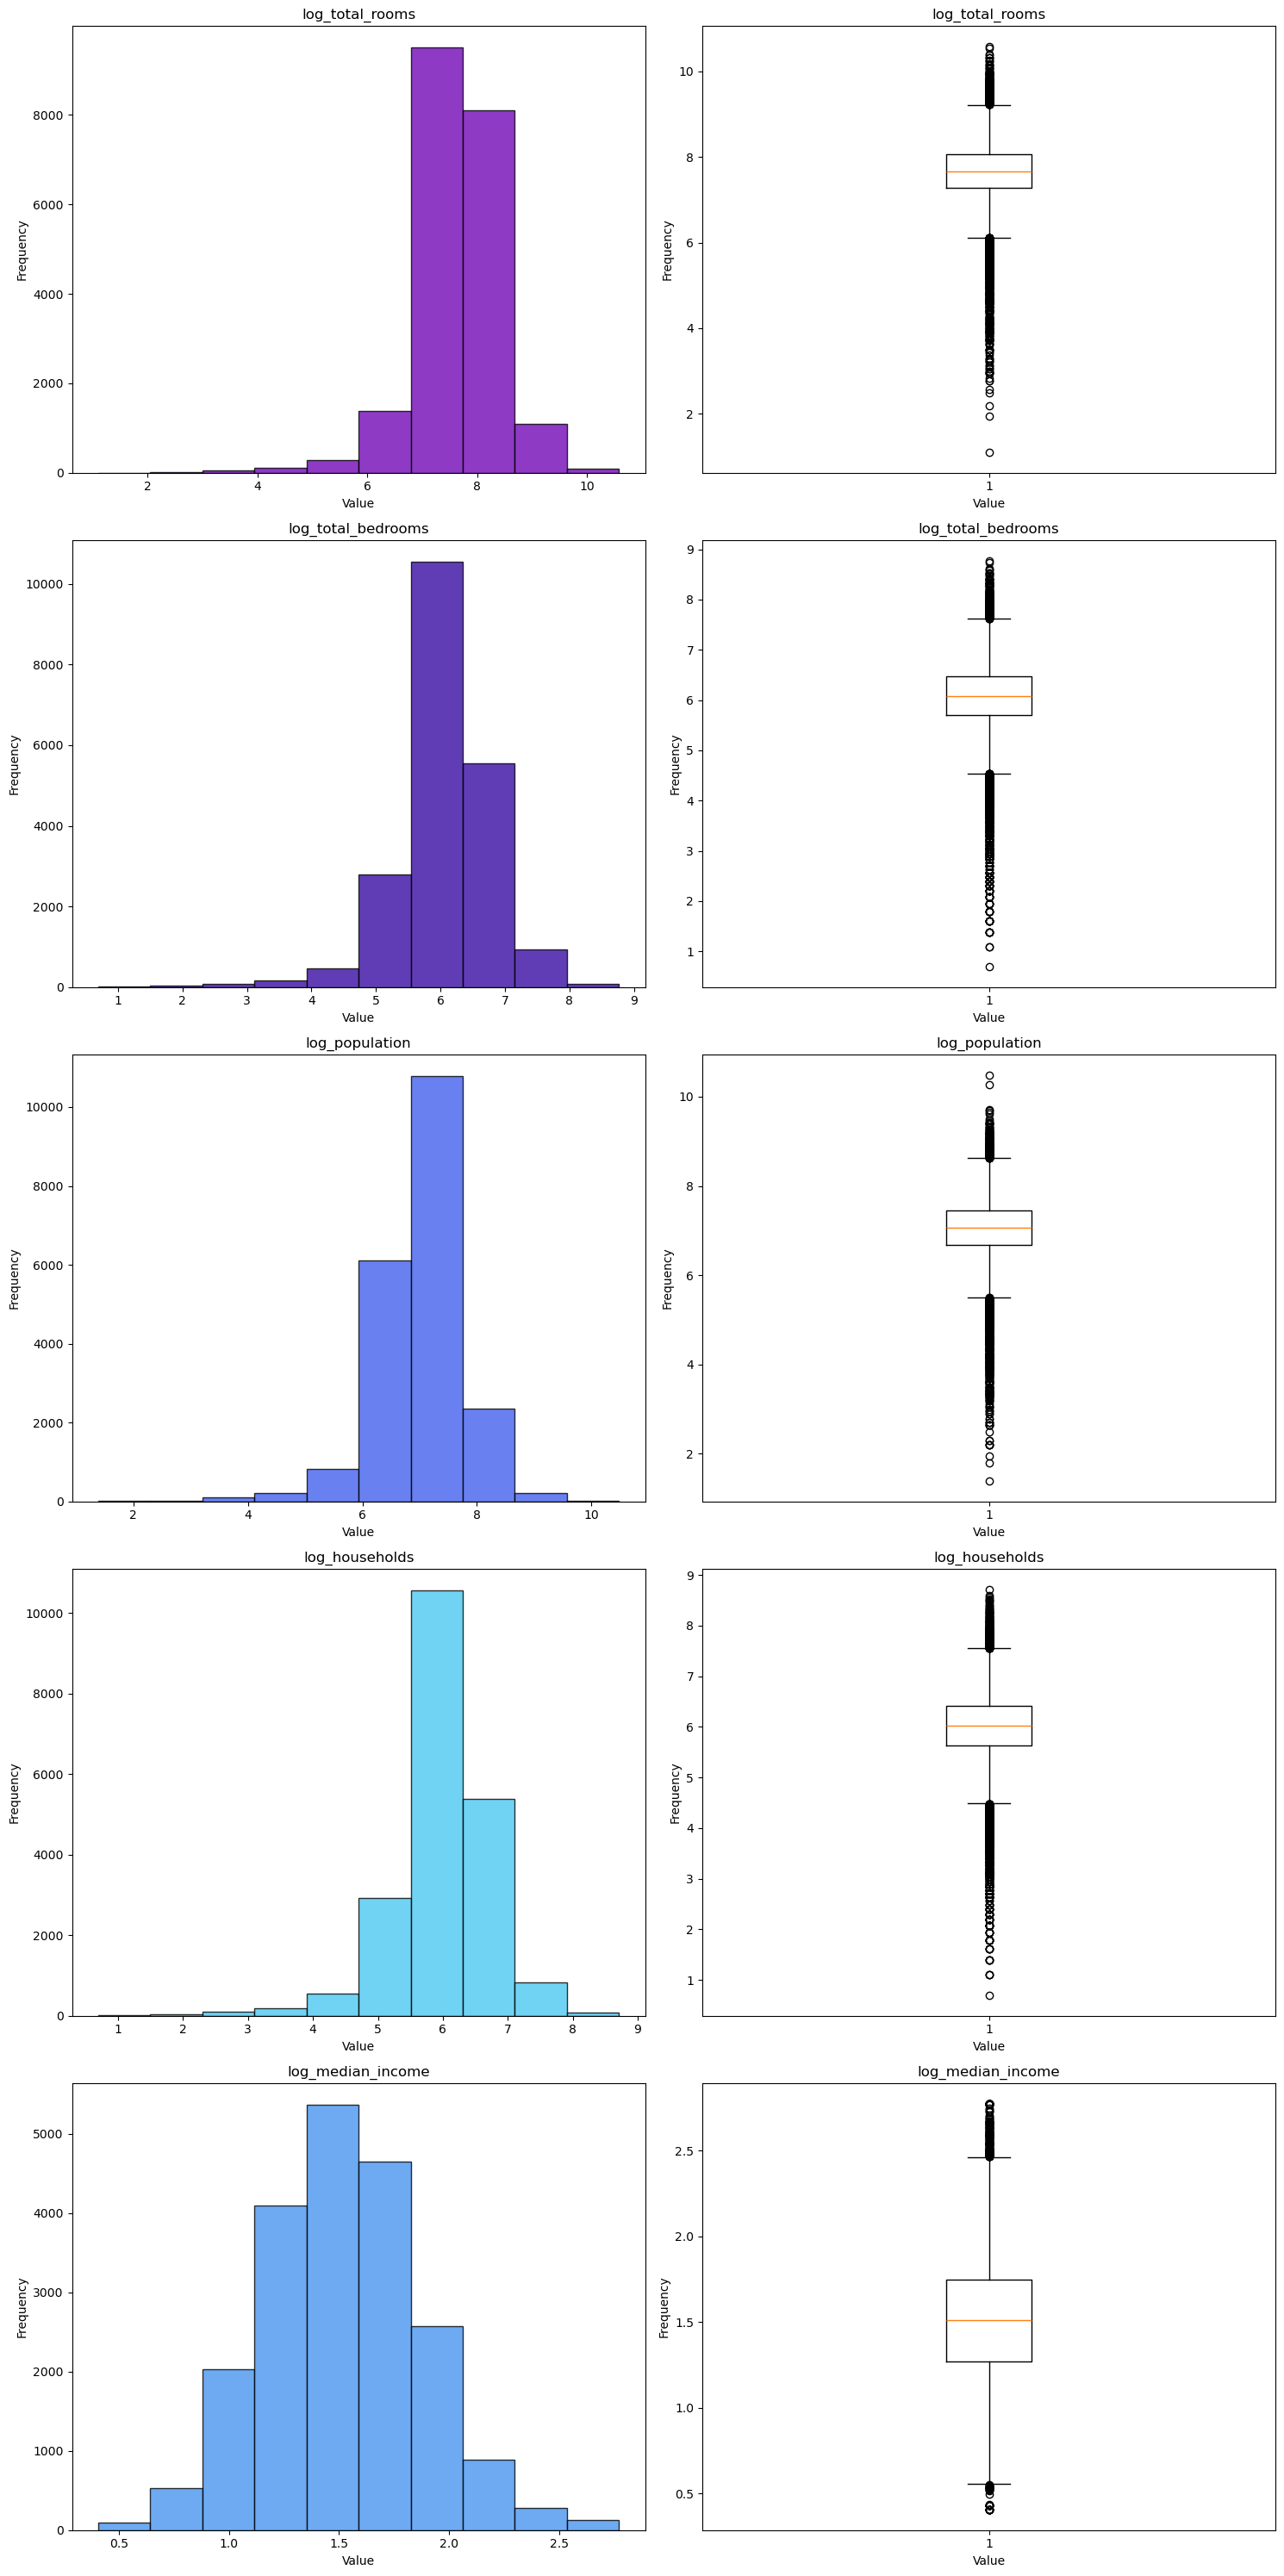

In [14]:
univariate_plot(data, 7, 12)

## Scaling Columns

In [15]:
data.head(1)

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income,<1h ocean,inland,near ocean,island
0,-122.23,37.88,41.0,452600.0,0.146591,2.555556,6.984127,6.781058,4.867534,5.777652,4.844187,2.23272,0,0,0,0


In [16]:
data, stats = standard_scaling(data, 0, 12)

In [17]:
#checking
data.describe()

,longitude,latitude,housing_median_age,median_house_value,bedrooms_per_room,population_per_household,rooms_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households,log_median_income,<1h ocean,inland,near ocean,island
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,20640.000000,20640.000000,20640.000000,20640.000000
mean,-8.592610e-15,2.269330e-15,6.609700e-17,-9.914550e-17,1.542263e-16,3.786807e-18,7.711317e-17,-1.046536e-15,8.262125e-17,-9.501444e-16,7.711317e-16,-1.707506e-16,0.442636,0.317393,0.128779,0.000242
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.496710,0.465473,0.334963,0.015563
min,-2.385935e+00,-1.447533e+00,-2.196127e+00,-1.662601e+00,-2.707251e+00,-2.289944e-01,-1.852274e+00,-8.707789e+00,-7.415233e+00,-7.659496e+00,-7.281218e+00,-3.099154e+00,0.000000,0.000000,0.000000,0.000000
25%,-1.113182e+00,-7.967694e-01,-8.453727e-01,-7.561450e-01,-5.911186e-01,-6.170912e-02,-3.994399e-01,-4.678995e-01,-4.948911e-01,-4.835458e-01,-4.765767e-01,-6.866334e-01,0.000000,0.000000,0.000000,0.000000
50%,5.389006e-01,-6.422715e-01,2.864502e-02,-2.353280e-01,-1.629927e-01,-2.431526e-02,-8.078293e-02,4.474857e-02,3.139900e-02,4.983314e-02,4.328229e-02,-1.453691e-02,0.000000,0.000000,0.000000,0.000000
75%,7.784775e-01,9.729330e-01,6.642943e-01,5.014851e-01,4.035696e-01,2.037404e-02,2.519554e-01,5.672913e-01,5.713745e-01,5.814146e-01,5.809197e-01,6.441170e-01,1.000000,1.000000,0.000000,0.000000
max,2.625216e+00,2.957996e+00,1.856137e+00,2.540349e+00,4.001463e+01,1.194162e+02,5.516190e+01,3.933563e+00,3.756548e+00,4.695397e+00,3.754506e+00,3.500638e+00,1.000000,1.000000,1.000000,1.000000


## Save the New DataSet

In [18]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data.iloc[:split, :].to_csv('../data/processed/training_data.csv', index=False)
data.iloc[split:, :].to_csv('../data/processed/testing_data.csv', index=False)

## Preparing the Dataset for Binary Classification

Y ('median_house_value') is divided into 2 classes:

    cheap: less than 300K$
    expensive: greater than 300K$

In [19]:
original_mean = stats['median_house_value'][0]
original_std = stats['median_house_value'][1]

In [20]:
data_copy = data.copy()
data_copy['median_house_value'] = binary_classification_formulation(data_copy['median_house_value'], original_mean, original_std )

c:\Users\PC\Documents\House Prediction Project\src\clean.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[cheap_mask]= 0
c:\Users\PC\Documents\House Prediction Project\src\clean.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[expensive_mask] = 1


In [21]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data_copy.iloc[:split, :].to_csv('../data/classification/binary/training_data.csv', index=False)
data_copy.iloc[split:, :].to_csv('../data/classification/binary/testing_data.csv', index=False)

## Preparing the Dataset for Classification (4 classes)

Y ('median_house_value') is divided into 4 classes: 

    cheap: less than 150K$
    moderate: between 150K$ and 250K$
    expensive: between 250K$ and 350K$
    very expensive: greater than 350K$
    

In [22]:

data['median_house_value'] = classification_formulation(data['median_house_value'], original_mean, original_std )

c:\Users\PC\Documents\House Prediction Project\src\clean.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_column.loc[cheap_mask]= "cheap"
c:\Users\PC\Documents\House Prediction Project\src\clean.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cheap' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  Y_column.loc[cheap_mask]= "cheap"


In [23]:
"""
training_set: 80%
testing_set: 20%
"""
split = int(0.8*len(data))

data.iloc[:split, :].to_csv('../data/classification/4_classes/training_data.csv', index=False)
data.iloc[split:, :].to_csv('../data/classification/4_classes/testing_data.csv', index=False)